In [1]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
from featuregraph.behaviors.transition2 import Transition

from featuregraph.operators.states import (
    rising_state,
    stable_state,
)

from featuregraph.operators.measures import (
    signal_measure
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

Python: /workspaces/featuregraph/.venv/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [2]:
bit = [{"state": "stable", "target": 1.0, "duration": 40},
    {"state": "falling", "target": 0.2, "duration": 1},
    {"state": "stable", "target": 0.2, "duration": 20},
    {"state": "rising", "target": 1.0, "duration": 1},]
segments = []
for i in range(10):
    segments.extend([b for b in bit])

pulse = fg.datasets.pulse(
    segments,
    initial_value=1.0,
    sample_interval=0.01,
    signal_name="pulse",
)

In [3]:
pulse_transition = Transition(
    pulse,
    signal='pulse',
    direction='stable',
    op=stable_state,
    diff_lag=10
)

df = pulse_transition.df

In [4]:
df

,sample,time,pulse,true_state,true_segment_id,pulse_stable,enter_pulse_stable,exit_pulse_stable,pulse_stable_rate_of_change,pulse_id
0,0,0.00,1.0,stable,0,False,False,False,NaN,0
1,1,0.01,1.0,stable,0,True,True,False,0.0,1
2,2,0.02,1.0,stable,0,True,False,False,0.0,1
3,3,0.03,1.0,stable,0,True,False,False,0.0,1
4,4,0.04,1.0,stable,0,True,False,False,0.0,1
...,...,...,...,...,...,...,...,...,...,...
615,615,6.15,0.2,stable,38,True,False,False,0.0,20
616,616,6.16,0.2,stable,38,True,False,False,0.0,20
617,617,6.17,0.2,stable,38,True,False,False,0.0,20
618,618,6.18,0.2,stable,38,True,False,False,0.0,20


In [5]:
df.dtypes

sample                           int64
time                           float64
pulse                          float64
true_state                         str
true_segment_id                  int64
pulse_stable                      bool
enter_pulse_stable                bool
exit_pulse_stable                 bool
pulse_stable_rate_of_change    float64
pulse_id                         int64
dtype: object

In [6]:
df['pulse_high'] = signal_measure(df, 'pulse', 'median', 'pulse_id', 'max')
df['pulse_low'] = signal_measure(df, 'pulse', 'median', 'pulse_id', 'min')


(<Figure size 1600x1540 with 7 Axes>,
 array([<Axes: ylabel='pulse'>, <Axes: ylabel='pulse_stable'>,
        <Axes: ylabel='enter_pulse_stable'>, <Axes: ylabel='pulse_id'>,
        <Axes: ylabel='true_segment_id'>, <Axes: ylabel='pulse_high'>,
        <Axes: xlabel='Time', ylabel='pulse_low'>], dtype=object))

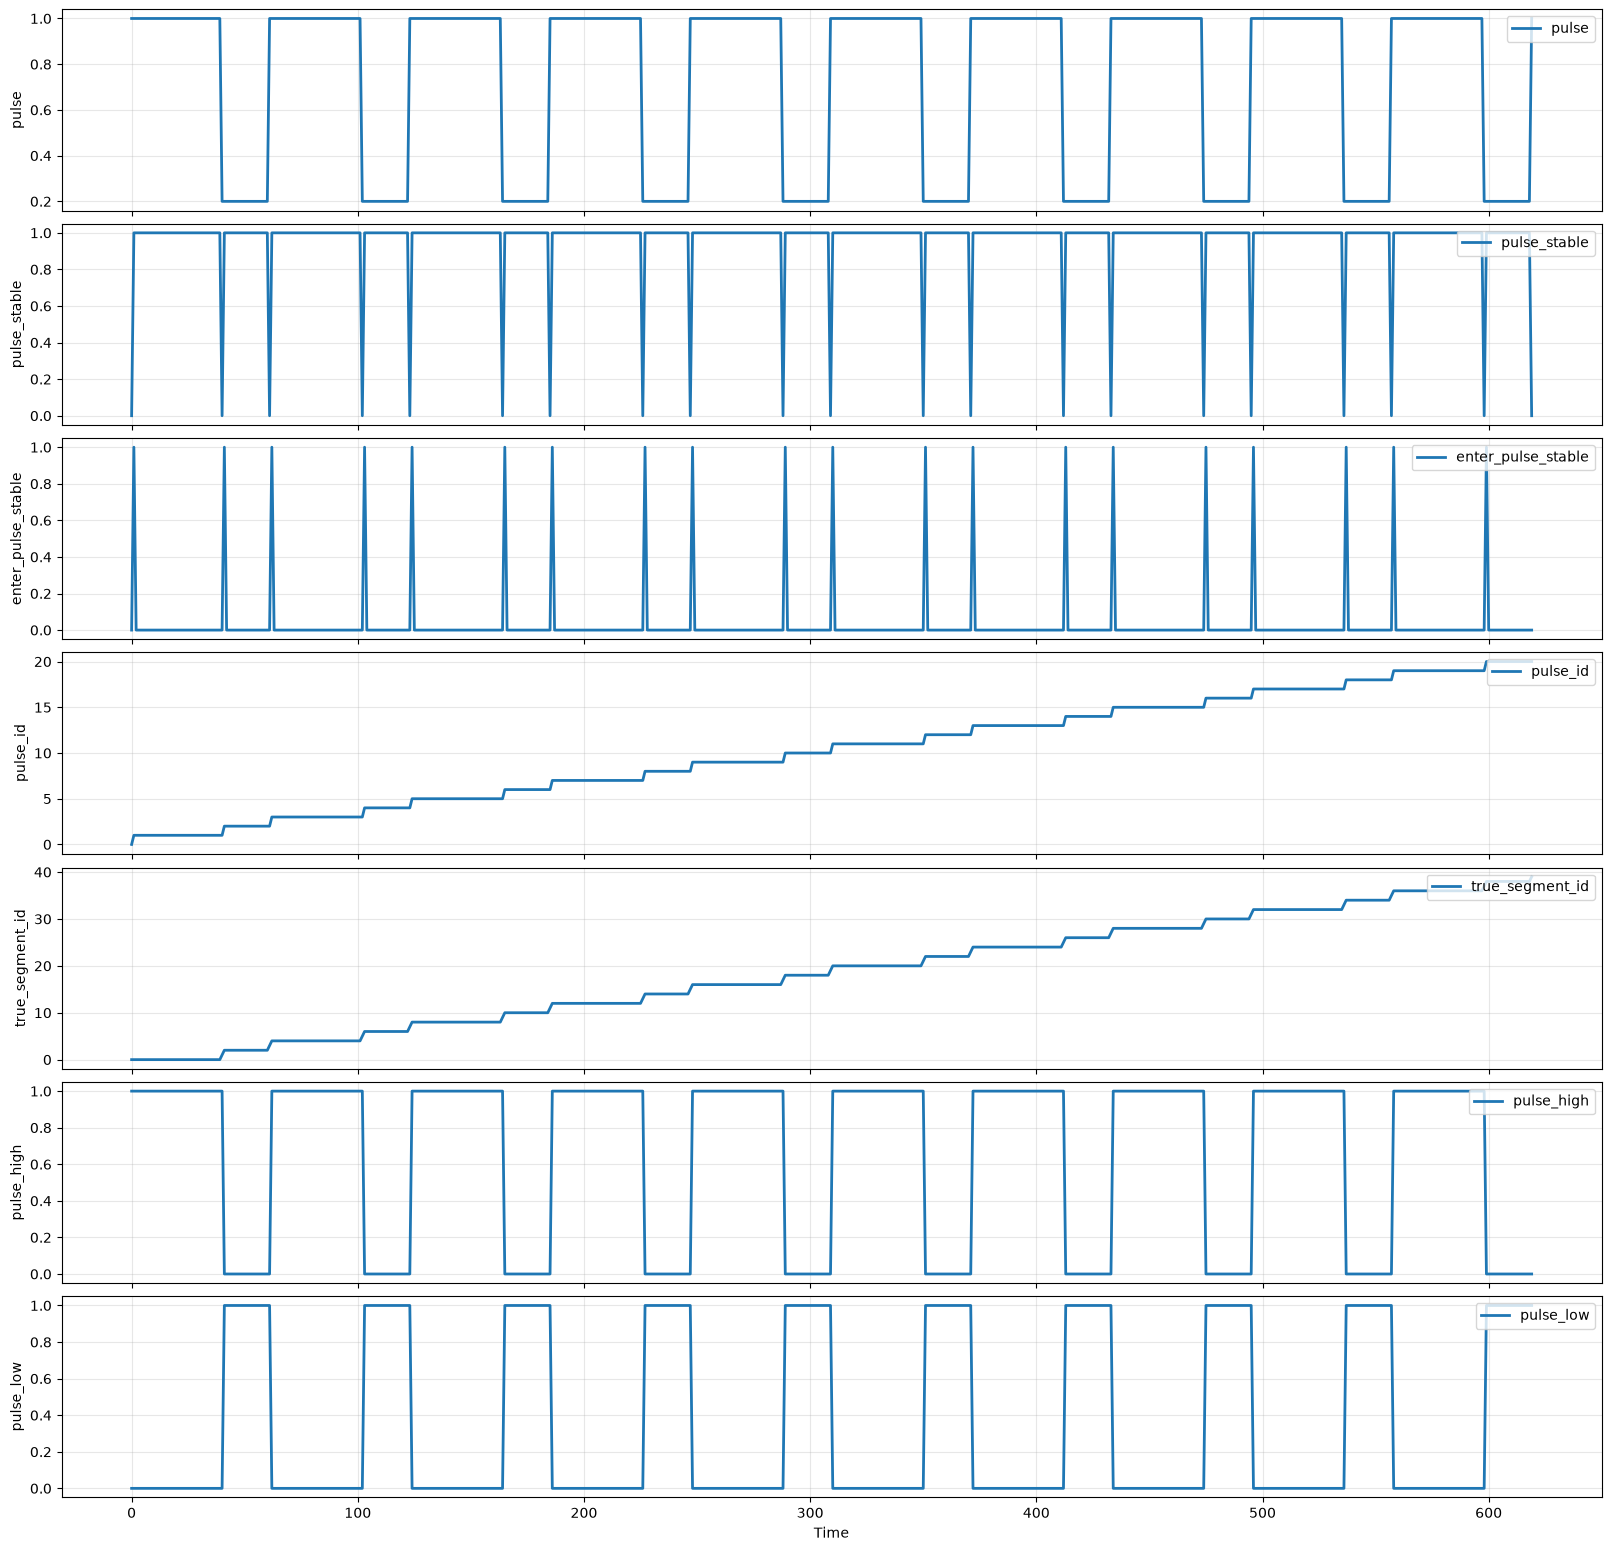

In [7]:
fg.plot(df, [['pulse'],
                ['pulse_stable'],
                ['enter_pulse_stable'],
                ['pulse_id'],
                ['true_segment_id'],
                ['pulse_high'],
                ['pulse_low']
                ])

In [8]:
summarydf = pulse_transition.summary()

In [9]:
summarydf

,duration,start_value,end_value,peak_rate_of_change,net_change,mean_rate
pulse_id,,,,,,
0,0,1.0,1.0,NaN,0.0,NaN
1,39,1.0,0.2,0.0,-0.8,-0.020513
2,20,0.2,1.0,0.8,0.8,0.040000
3,40,1.0,0.2,0.0,-0.8,-0.020000
4,20,0.2,1.0,0.8,0.8,0.040000
5,40,1.0,0.2,0.0,-0.8,-0.020000
6,20,0.2,1.0,0.8,0.8,0.040000
7,40,1.0,0.2,0.0,-0.8,-0.020000
8,20,0.2,1.0,0.8,0.8,0.040000
